# Практическая работа 2: поиск ассоциативных правил


## 1. Задание

1. Выполнить поиск ассоциативных правил для набора данных `baskets.csv`.
2. Зафиксировать пороговое значение поддержки.
3. Варьировать порог достоверности от `70%` до `95%` с шагом `5%`.
4. Получить список правил в формате `антецедент ==> консеквент`.
5. Отфильтровать правила, в которых антецедент и консеквент суммарно содержат не более 7 объектов.
6. Проанализировать содержательный смысл полученных результатов.


In [53]:
from __future__ import annotations

import csv
import os
from collections import Counter
from collections.abc import Sequence
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (6, 4)

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 300)


In [54]:
DATA_PATH = Path("baskets.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError("Файл baskets.csv не найден. Запустите ноутбук из каталога практики.")


## 2. Обзор данных


In [55]:
def load_transactions(path: Path) -> list[list[str]]:
    """Загружает транзакции из CSV-файла.

    Каждая строка файла интерпретируется как одна транзакция,
    элементы очищаются от пробелов и дедуплицируются внутри транзакции.

    :param path: Путь до CSV-файла с корзинами покупок.
    :return: Список транзакций, где транзакция — список товаров.
    """
    transactions: list[list[str]] = []
    with path.open(encoding="utf-8") as file:
        reader = csv.reader(file)
        for row in reader:
            items = sorted({value.strip() for value in row if value and value.strip()})
            if items:
                transactions.append(items)
    return transactions


In [56]:
transactions = load_transactions(DATA_PATH)
n_transactions = len(transactions)
print(f"Транзакций: {n_transactions}")


Транзакций: 7501


In [57]:
def build_dataset_overview(transactions: Sequence[Sequence[str]]) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Формирует сводную статистику, топ-15 товаров и распределение размеров корзин.

    :param transactions: Коллекция транзакций.
    :return: Кортеж из трех DataFrame:
        1) общая статистика датасета;
        2) топ-15 товаров по частоте и поддержке;
        3) распределение корзин по их размеру.
    """
    basket_sizes = pd.Series([len(transaction) for transaction in transactions], name="Размер корзины")
    item_counter = Counter(item for transaction in transactions for item in transaction)

    summary_frame = pd.DataFrame(
        {
            "Показатель": [
                "Количество транзакций",
                "Количество уникальных товаров",
                "Средний размер корзины",
                "Минимальный размер корзины",
                "Максимальный размер корзины",
            ],
            "Значение": [
                len(transactions),
                len(item_counter),
                round(float(basket_sizes.mean()), 3),
                int(basket_sizes.min()),
                int(basket_sizes.max()),
            ],
        }
    )

    top_items_frame = pd.DataFrame(item_counter.most_common(15), columns=["Товар", "Количество"])
    top_items_frame["Поддержка"] = (top_items_frame["Количество"] / len(transactions)).round(4)

    basket_size_distribution = (
        basket_sizes.value_counts()
        .sort_index()
        .rename_axis("Размер корзины")
        .reset_index(name="Количество корзин")
    )

    return summary_frame, top_items_frame, basket_size_distribution


In [58]:
def plot_top_items_support(top_items_frame: pd.DataFrame) -> None:
    """Строит горизонтальную диаграмму поддержки для топ-15 товаров.

    :param top_items_frame: Таблица с колонками "Товар" и "Поддержка".
    :return: None.
    """
    plot_frame = top_items_frame.sort_values("Поддержка", ascending=True)
    plt.figure(figsize=(10, 6), dpi=120)
    plt.barh(plot_frame["Товар"], plot_frame["Поддержка"] * 100, color="#4c78a8")
    plt.title("Топ-15 товаров по поддержке")
    plt.xlabel("Поддержка, %")
    plt.ylabel("Товар")
    plt.tight_layout()
    plt.show()


,Показатель,Значение
0,Количество транзакций,7501.000
1,Количество уникальных товаров,115.000
2,Средний размер корзины,3.909
3,Минимальный размер корзины,1.000
4,Максимальный размер корзины,20.000


,Товар,Количество,Поддержка
0,минеральная вода,1788,0.2384
1,макароны,1410,0.1880
2,яйца,1348,0.1797
3,картофель-фри,1282,0.1709
4,шоколад,1229,0.1638
5,зеленый чай,991,0.1321
6,молоко,972,0.1296
7,говяжий фарш,737,0.0983
8,замороженные овощи,715,0.0953
9,блинчики,713,0.0951


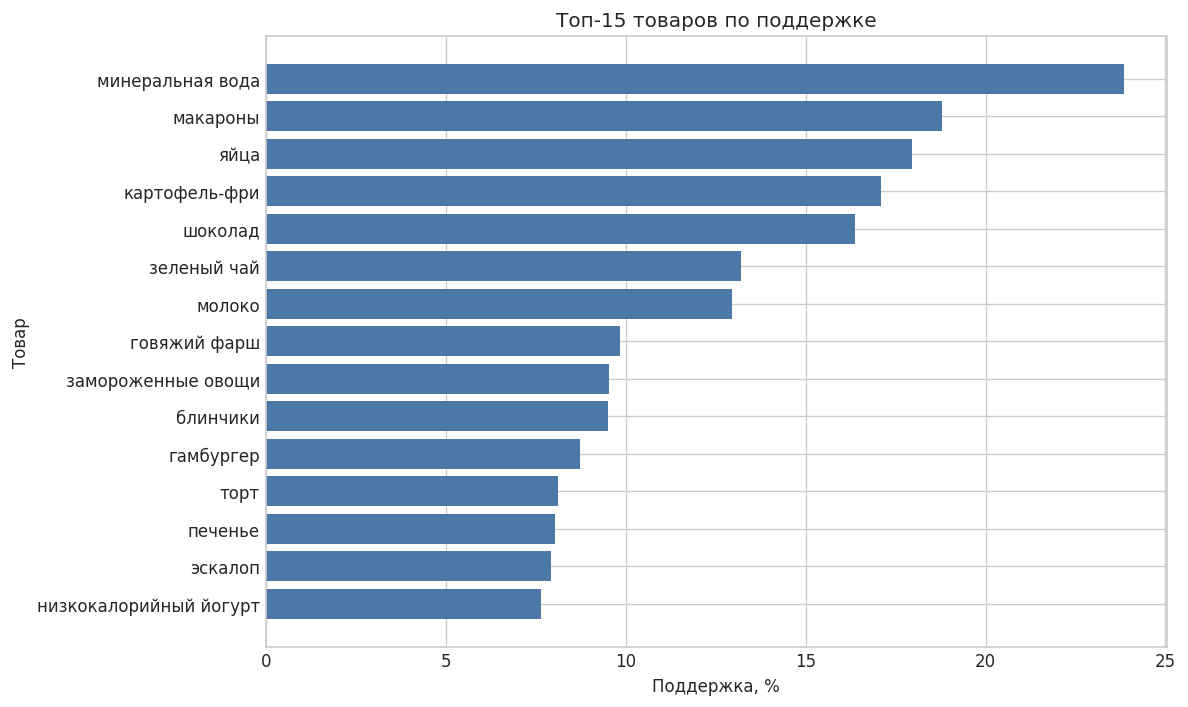

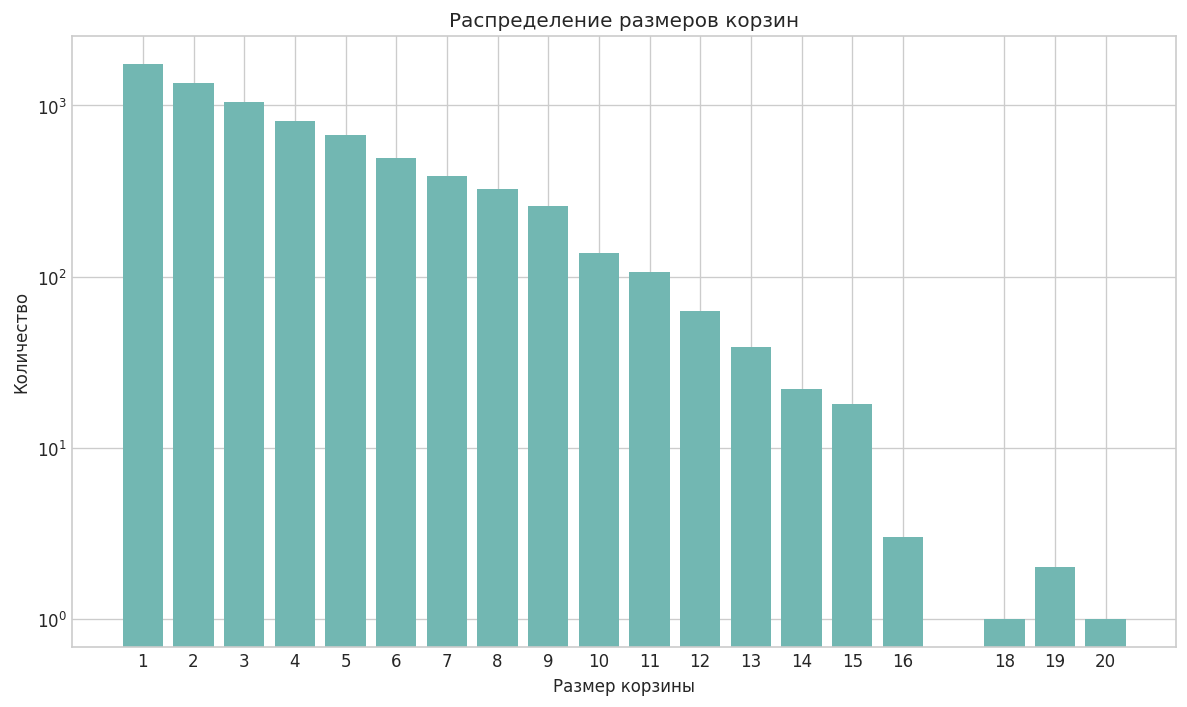

In [59]:
def plot_basket_size_distribution(basket_size_df: pd.DataFrame) -> None:
    """Строит распределение количества корзин по числу товаров в них.

    :param basket_size_df: Таблица с колонками "Размер корзины" и "Количество корзин".
    :return: None.
    """
    plt.figure(figsize=(10, 6), dpi=120)
    plt.bar(
        basket_size_df["Размер корзины"],
        basket_size_df["Количество корзин"],
        color="#72b7b2",
    )
    plt.title("Распределение размеров корзин")
    plt.xlabel("Размер корзины")
    plt.ylabel("Количество")
    plt.yscale("log")
    plt.xticks(basket_size_df["Размер корзины"])
    plt.tight_layout()
    plt.show()
summary_df, item_freq_df, basket_size_df = build_dataset_overview(transactions)
display(summary_df)
display(item_freq_df)
plot_top_items_support(item_freq_df)
plot_basket_size_distribution(basket_size_df)


## 3. Реализация

In [60]:
def encode_transactions(transactions: Sequence[Sequence[str]]) -> pd.DataFrame:
    """Преобразует транзакции в one-hot матрицу для алгоритма apriori.

    :param transactions: Список транзакций (товары в каждой корзине).
    :return: DataFrame, где строки — транзакции, столбцы — товары, значения — bool.
    """
    encoder = TransactionEncoder()
    matrix = encoder.fit(transactions).transform(transactions)
    return pd.DataFrame(matrix, columns=encoder.columns_)


In [61]:
def evaluate_support_levels(
    basket_df: pd.DataFrame,
    support_levels: Sequence[float],
    confidence_levels: Sequence[float],
) -> pd.DataFrame:
    """Оценивает число частых наборов и правил при разных порогах поддержки.

    :param basket_df: One-hot представление транзакций.
    :param support_levels: Набор кандидатных порогов поддержки.
    :param confidence_levels: Пороги достоверности для расчета числа правил.
    :return: DataFrame со сводными метриками по каждому значению поддержки.
    """
    rows: list[dict[str, float | int]] = []
    for support in support_levels:
        frequent_itemsets = apriori(basket_df, min_support=support, use_colnames=True)
        all_rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0)
        max_confidence = float(all_rules['confidence'].max()) if not all_rules.empty else 0.0

        row: dict[str, float | int] = {
            'support_value': support,
            'Поддержка, %': round(support * 100, 3),
            'Частых наборов всего': len(frequent_itemsets),
            'Частых наборов длины >= 2': int((frequent_itemsets['itemsets'].apply(len) >= 2).sum()),
            'Макс. confidence, %': round(max_confidence * 100, 3),
        }
        for confidence in confidence_levels:
            rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=confidence)
            row[f'Правил при confidence >= {int(confidence * 100)}%'] = len(rules)
        rows.append(row)
    return pd.DataFrame(rows)


In [62]:
def choose_support_level(support_probe_df: pd.DataFrame, confidence_levels: Sequence[float]) -> float:
    """Выбирает максимальную поддержку, при которой правила есть на всех confidence-порогах.

    :param support_probe_df: Таблица диагностики по поддержке (результат evaluate_support_levels).
    :param confidence_levels: Проверяемые уровни достоверности.
    :return: Оптимальное значение поддержки для основного эксперимента.
    :raises ValueError: Если не найдено ни одного правила даже при минимальном confidence.
    """
    rule_columns = [f'Правил при confidence >= {int(confidence * 100)}%' for confidence in confidence_levels]
    all_conf_mask = (support_probe_df[rule_columns] > 0).all(axis=1)

    if all_conf_mask.any():
        return float(support_probe_df.loc[all_conf_mask, 'support_value'].max())

    fallback_mask = support_probe_df[rule_columns[0]] > 0
    if fallback_mask.any():
        return float(support_probe_df.loc[fallback_mask, 'support_value'].max())

    raise ValueError('Не удалось подобрать порог поддержки: правила не найдены даже при confidence=70%.')


In [63]:
def plot_support_diagnostics(support_probe_df: pd.DataFrame, confidence_levels: Sequence[float]) -> None:
    """Строит диагностические графики для выбора порога поддержки.

    :param support_probe_df: Таблица с метриками по кандидатным поддержкам.
    :param confidence_levels: Список confidence-порогов, отображаемых на графике.
    :return: None.
    """
    plot_df = support_probe_df.sort_values('support_value', ascending=False).copy()
    plot_df['support_label'] = plot_df['Поддержка, %'].map(lambda value: f'{value:g}')

    plt.figure(figsize=(10, 6), dpi=120)
    plt.plot(plot_df['support_label'], plot_df['Макс. confidence, %'], marker='o', linewidth=2, color='#6f42c1')
    plt.axhline(70, color='black', linestyle='--', linewidth=1, label='Порог 70%')
    plt.title('Максимальная достижимая достоверность по порогам поддержки')
    plt.xlabel('Поддержка, %')
    plt.ylabel('Максимальный confidence, %')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6), dpi=120)
    for confidence in confidence_levels:
        column = f'Правил при confidence >= {int(confidence * 100)}%'
        plt.plot(
            plot_df['support_label'],
            plot_df[column],
            marker='o',
            linewidth=2,
            label=f'confidence >= {int(confidence * 100)}%',
        )
    plt.title('Количество правил при разных сочетаниях support/confidence')
    plt.xlabel('Поддержка, %')
    plt.ylabel('Количество правил')
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()


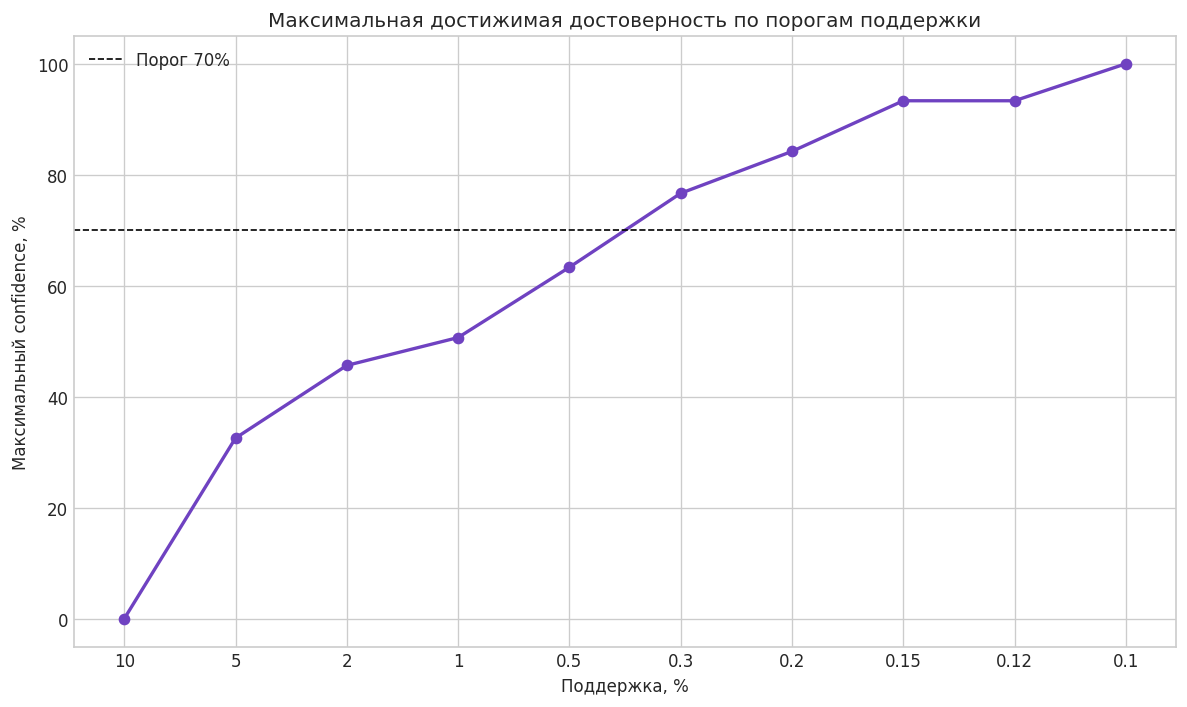

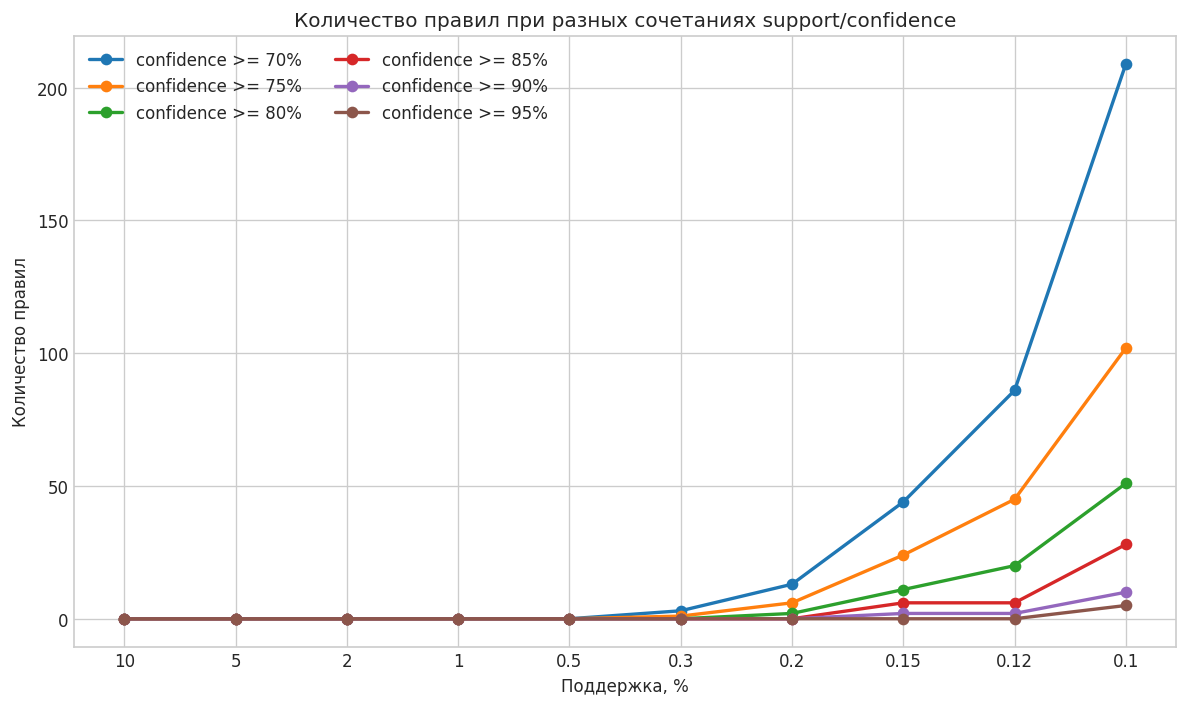

Выбранный порог поддержки для основного эксперимента: 0.100%


In [64]:
CONFIDENCE_LEVELS = [level / 100 for level in range(70, 100, 5)]
SUPPORT_CANDIDATES = [0.10, 0.05, 0.02, 0.01, 0.005, 0.003, 0.002, 0.0015, 0.0012, 0.001]

basket_df = encode_transactions(transactions)
support_probe_df = evaluate_support_levels(
    basket_df=basket_df,
    support_levels=SUPPORT_CANDIDATES,
    confidence_levels=CONFIDENCE_LEVELS,
)
plot_support_diagnostics(support_probe_df, CONFIDENCE_LEVELS)

selected_support = choose_support_level(support_probe_df, CONFIDENCE_LEVELS)
print(f'Выбранный порог поддержки для основного эксперимента: {selected_support * 100:.3f}%')


Для основного эксперимента берем **максимальную** поддержку,
при которой правила существуют для всех порогов `confidence` от `70%` до `95%`.

Выбор подтверждается диагностическими графиками выше.
Из проверенных кандидатов условию удовлетворяет `0.1%` (`0.001`).


In [65]:
def itemset_to_text(itemset: frozenset[str]) -> str:
    """Преобразует множество товаров в детерминированную строку для печати правила.

    :param itemset: Набор товаров (frozenset), входящих в антецедент или консеквент.
    :return: Строка товаров, отсортированная и разделенная запятыми.
    """
    return ', '.join(sorted(itemset))


In [66]:
def build_rules_catalog(
    frequent_itemsets: pd.DataFrame,
    confidence_levels: Sequence[float],
) -> tuple[pd.DataFrame, pd.DataFrame, dict[float, pd.DataFrame]]:
    """Строит каталог ассоциативных правил и агрегированные метрики по confidence.

    :param frequent_itemsets: DataFrame частых наборов, полученный apriori.
    :param confidence_levels: Список confidence-порогов для экспериментов.
    :return: Кортеж из трех объектов: metrics_df, catalog_df, rules_by_threshold.
    """
    metrics_rows: list[dict[str, float | int]] = []
    catalog_rows: list[dict[str, float | int | str]] = []
    rules_by_threshold: dict[float, pd.DataFrame] = {}

    for min_confidence in confidence_levels:
        started = perf_counter()
        rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=min_confidence)
        elapsed = perf_counter() - started

        if rules.empty:
            prepared = rules.copy()
            max_rule_len = 0
            rules_up_to_7 = 0
        else:
            prepared = rules.copy()
            prepared['antecedent_len'] = prepared['antecedents'].apply(len)
            prepared['consequent_len'] = prepared['consequents'].apply(len)
            prepared['rule_len'] = prepared['antecedent_len'] + prepared['consequent_len']
            prepared['rule'] = (
                prepared['antecedents'].apply(itemset_to_text)
                + ' ==> '
                + prepared['consequents'].apply(itemset_to_text)
            )
            prepared = prepared.sort_values(['confidence', 'lift', 'support'], ascending=[False, False, False]).reset_index(drop=True)

            max_rule_len = int(prepared['rule_len'].max())
            rules_up_to_7 = int((prepared['rule_len'] <= 7).sum())

            catalog_rows.extend(
                {
                    'Порог достоверности, %': int(min_confidence * 100),
                    'Правило': row.rule,
                    'Поддержка, %': round(row.support * 100, 4),
                    'Достоверность, %': round(row.confidence * 100, 2),
                    'Lift': round(row.lift, 4),
                    'Объектов в правиле': int(row.rule_len),
                }
                for row in prepared.itertuples()
            )

        metrics_rows.append(
            {
                'confidence_threshold': min_confidence,
                'runtime_sec': elapsed,
                'total_rules': len(prepared),
                'max_items_in_rule': max_rule_len,
                'rules_with_max_7_items': rules_up_to_7,
            }
        )
        rules_by_threshold[min_confidence] = prepared

    metrics_df = pd.DataFrame(metrics_rows)
    catalog_df = pd.DataFrame(catalog_rows)
    return metrics_df, catalog_df, rules_by_threshold


In [67]:
def format_metrics(metrics_df: pd.DataFrame) -> pd.DataFrame:
    """Преобразует технические метрики в удобный для отчета формат.

    :param metrics_df: Сырые метрики из build_rules_catalog.
    :return: DataFrame с русскими названиями колонок и человекочитаемыми единицами.
    """
    return (
        metrics_df.assign(
            **{
                'Порог достоверности, %': (metrics_df['confidence_threshold'] * 100).astype(int),
                'Время поиска, мс': (metrics_df['runtime_sec'] * 1000).round(3),
                'Количество правил': metrics_df['total_rules'].astype(int),
                'Максимум объектов в правиле': metrics_df['max_items_in_rule'].astype(int),
                'Правил с суммарной длиной <= 7': metrics_df['rules_with_max_7_items'].astype(int),
            }
        )[
            [
                'Порог достоверности, %',
                'Время поиска, мс',
                'Количество правил',
                'Максимум объектов в правиле',
                'Правил с суммарной длиной <= 7',
            ]
        ]
    )


In [68]:
MIN_SUPPORT = selected_support

frequent_itemsets = apriori(basket_df, min_support=MIN_SUPPORT, use_colnames=True)
metrics_df, rules_catalog_df, rules_by_threshold = build_rules_catalog(
    frequent_itemsets=frequent_itemsets,
    confidence_levels=CONFIDENCE_LEVELS,
)
metrics_view = format_metrics(metrics_df)

print(f'Частых наборов при поддержке {MIN_SUPPORT * 100:.3f}%: {len(frequent_itemsets)}')
display(metrics_view)


Частых наборов при поддержке 0.100%: 6938


,"Порог достоверности, %","Время поиска, мс",Количество правил,Максимум объектов в правиле,Правил с суммарной длиной <= 7
0,70,35.615,209,6,209
1,75,23.100,102,6,102
2,80,22.352,51,6,51
3,85,23.619,28,6,28
4,90,22.403,10,5,10
5,95,22.819,5,5,5


### 3.1 Список правил в формате `антецедент ==> консеквент`

Ниже показаны первые 50 правил для всех порогов достоверности.


In [69]:
def prepare_rule_tables(rules_catalog_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Подготавливает полный список правил и сводку по фильтру длины правила.

    :param rules_catalog_df: Каталог правил с колонкой "Объектов в правиле".
    :return: Кортеж (full_table, filtered_counts), где filtered_counts содержит число правил с длиной <= 7.
    """
    if rules_catalog_df.empty:
        return rules_catalog_df, pd.DataFrame(columns=['Порог достоверности, %', 'Количество правил с длиной <= 7'])

    full_table = rules_catalog_df.sort_values(
        ['Порог достоверности, %', 'Достоверность, %', 'Lift'],
        ascending=[True, False, False],
    ).reset_index(drop=True)

    filtered_table = full_table[full_table['Объектов в правиле'] <= 7].copy()
    filtered_counts = (
        filtered_table.groupby('Порог достоверности, %')
        .size()
        .rename('Количество правил с длиной <= 7')
        .reset_index()
    )
    return full_table, filtered_counts


In [70]:
def plot_filtered_rule_counts(filtered_counts_df: pd.DataFrame) -> None:
    """Строит столбчатую диаграмму количества правил с суммарной длиной не более 7.

    :param filtered_counts_df: Сводная таблица с порогами confidence и числом отфильтрованных правил.
    :return: None.
    """
    plt.figure(figsize=(10, 6), dpi=120)
    plt.bar(
        filtered_counts_df['Порог достоверности, %'].astype(str),
        filtered_counts_df['Количество правил с длиной <= 7'],
        color='#e15759',
    )
    plt.title('Количество правил с суммарной длиной <= 7')
    plt.xlabel('Порог достоверности, %')
    plt.ylabel('Количество правил')
    plt.tight_layout()
    plt.show()


,"Порог достоверности, %",Правило,"Поддержка, %","Достоверность, %",Lift,Объектов в правиле
0,70,"минеральная вода, торт, фрикадельки ==> молоко",0.1067,100.00,7.7171,4
1,70,"говяжий фарш, низкокалорийный крем, оливковое масло ==> минеральная вода",0.1200,100.00,4.1952,4
2,70,"креветки, оливковое масло, торт ==> минеральная вода",0.1200,100.00,4.1952,4
3,70,"говяжий фарш, макароны, рис, травы и перец ==> минеральная вода",0.1200,100.00,4.1952,5
4,70,"блинчики, протеиновый батончик, шоколад ==> минеральная вода",0.1067,100.00,4.1952,4
5,70,"говяжий фарш, замороженные овощи, креветки, минеральная вода ==> макароны",0.1866,93.33,4.9652,5
6,70,"красное вино, суп ==> минеральная вода",0.1866,93.33,3.9155,3
7,70,"курица, помидоры, рис ==> минеральная вода",0.1200,90.00,3.7757,4
8,70,"замороженные овощи, индейка, макароны, молоко ==> минеральная вода",0.1200,90.00,3.7757,5
9,70,"замороженные овощи, креветки, оливковое масло, шоколад ==> минеральная вода",0.1200,90.00,3.7757,5


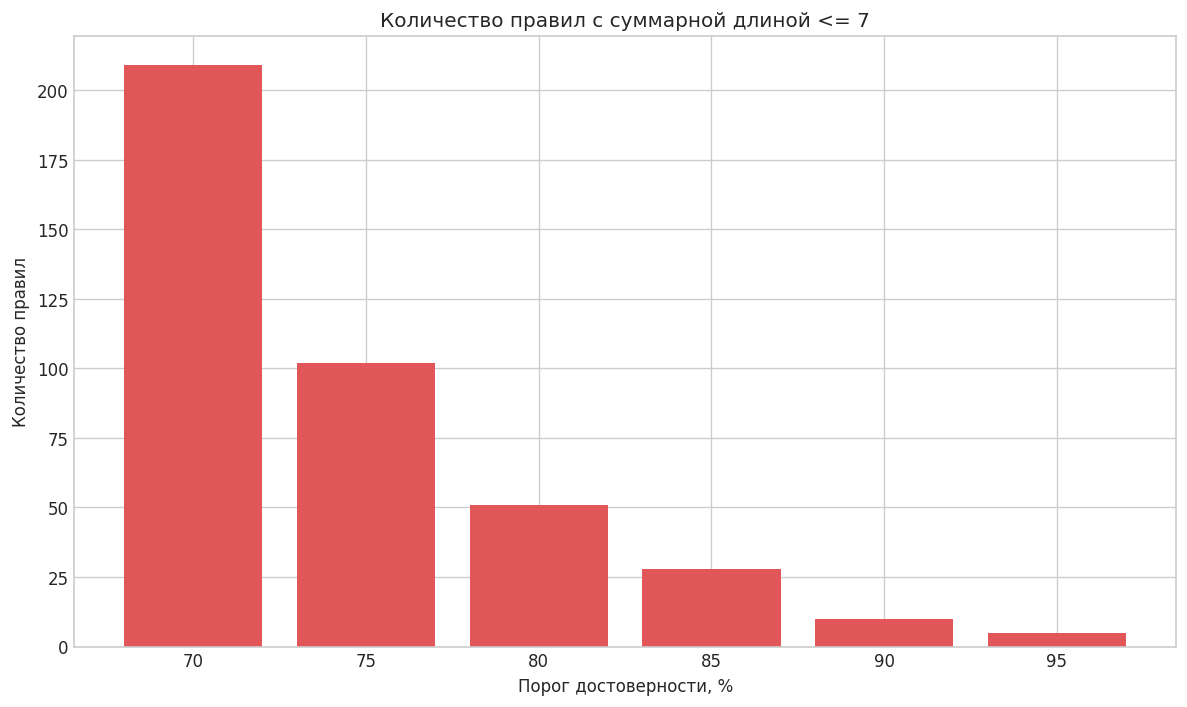

Всего правил: 405 | После фильтра (<= 7 объектов): 405


In [71]:
if rules_catalog_df.empty:
    display(Markdown('Правила не найдены для выбранных параметров.'))
else:
    full_rules_df, filtered_counts_df = prepare_rule_tables(rules_catalog_df)
    display(full_rules_df.head(50))
    plot_filtered_rule_counts(filtered_counts_df)
    print(f'Всего правил: {len(full_rules_df)} | После фильтра (<= 7 объектов): {int(filtered_counts_df["Количество правил с длиной <= 7"].sum())}')


## 4. Визуализации

In [72]:
def prepare_plot_df(metrics_df: pd.DataFrame) -> pd.DataFrame:
    """Готовит производные колонки для визуализаций раздела экспериментов.

    :param metrics_df: Таблица метрик с runtime_sec и confidence_threshold.
    :return: Копия DataFrame с дополнительными полями confidence_pct и runtime_ms.
    """
    plot_df = metrics_df.copy()
    plot_df['confidence_pct'] = (plot_df['confidence_threshold'] * 100).astype(int)
    plot_df['runtime_ms'] = plot_df['runtime_sec'] * 1000
    return plot_df


In [73]:
def plot_runtime_by_confidence(plot_df: pd.DataFrame) -> None:
    """Рисует график времени поиска правил в зависимости от confidence.

    :param plot_df: Подготовленная таблица метрик с колонками confidence_pct и runtime_ms.
    :return: None.
    """
    plt.figure(figsize=(10, 6), dpi=120)
    plt.plot(plot_df['confidence_pct'], plot_df['runtime_ms'], marker='o', linewidth=2, color='#1f77b4')
    plt.title('Сравнение быстродействия поиска правил')
    plt.xlabel('Порог достоверности, %')
    plt.ylabel('Время, мс')
    plt.xticks(plot_df['confidence_pct'])
    plt.tight_layout()
    plt.show()


In [74]:
def plot_total_rules_by_confidence(plot_df: pd.DataFrame) -> None:
    """Рисует график общего количества найденных правил по confidence.

    :param plot_df: Подготовленная таблица метрик с колонкой total_rules.
    :return: None.
    """
    plt.figure(figsize=(10, 6), dpi=120)
    plt.plot(plot_df['confidence_pct'], plot_df['total_rules'], marker='o', linewidth=2, color='#2ca02c')
    plt.title('Общее количество найденных правил')
    plt.xlabel('Порог достоверности, %')
    plt.ylabel('Количество правил')
    plt.xticks(plot_df['confidence_pct'])
    plt.tight_layout()
    plt.show()


In [75]:
def plot_max_items_by_confidence(plot_df: pd.DataFrame) -> None:
    """Рисует диаграмму максимального размера правила при разных confidence.

    :param plot_df: Подготовленная таблица метрик с колонкой max_items_in_rule.
    :return: None.
    """
    plt.figure(figsize=(10, 6), dpi=120)
    plt.bar(plot_df['confidence_pct'], plot_df['max_items_in_rule'], color='#ff7f0e', width=3.5)
    plt.title('Максимальное количество объектов в правиле')
    plt.xlabel('Порог достоверности, %')
    plt.ylabel('Максимум объектов')
    plt.xticks(plot_df['confidence_pct'])
    plt.tight_layout()
    plt.show()


In [76]:
def plot_rule_length_distribution(rules_by_threshold: dict[float, pd.DataFrame]) -> None:
    """Строит накопленную диаграмму распределения правил по суммарной длине.

    :param rules_by_threshold: Словарь правил по порогам confidence.
    :return: None.
    """
    rows: list[dict[str, int]] = []
    all_lengths: set[int] = set()

    for confidence_threshold in sorted(rules_by_threshold.keys()):
        rules_df = rules_by_threshold[confidence_threshold]
        row: dict[str, int] = {'Порог достоверности, %': int(confidence_threshold * 100)}

        if not rules_df.empty and 'rule_len' in rules_df.columns:
            counts = rules_df['rule_len'].value_counts().to_dict()
            for length, count in counts.items():
                length_value = int(length)
                all_lengths.add(length_value)
                row[f'Длина {length_value}'] = int(count)

        rows.append(row)

    if not rows or not all_lengths:
        return

    length_df = pd.DataFrame(rows).sort_values('Порог достоверности, %')
    length_columns = [f'Длина {length}' for length in sorted(all_lengths)]

    for column in length_columns:
        if column not in length_df.columns:
            length_df[column] = 0

    length_df[length_columns] = length_df[length_columns].fillna(0).astype(int)

    x_labels = length_df['Порог достоверности, %'].astype(str).tolist()
    bottom = [0] * len(length_df)
    palette = ['#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

    plt.figure(figsize=(10, 6), dpi=120)
    for idx, column in enumerate(length_columns):
        values = length_df[column].tolist()
        plt.bar(
            x_labels,
            values,
            bottom=bottom,
            label=column,
            color=palette[idx % len(palette)],
        )
        bottom = [base + add for base, add in zip(bottom, values)]

    plt.title('Распределение правил по суммарной длине')
    plt.xlabel('Порог достоверности, %')
    plt.ylabel('Количество правил')
    plt.legend(title='Длина правила')
    plt.tight_layout()
    plt.show()


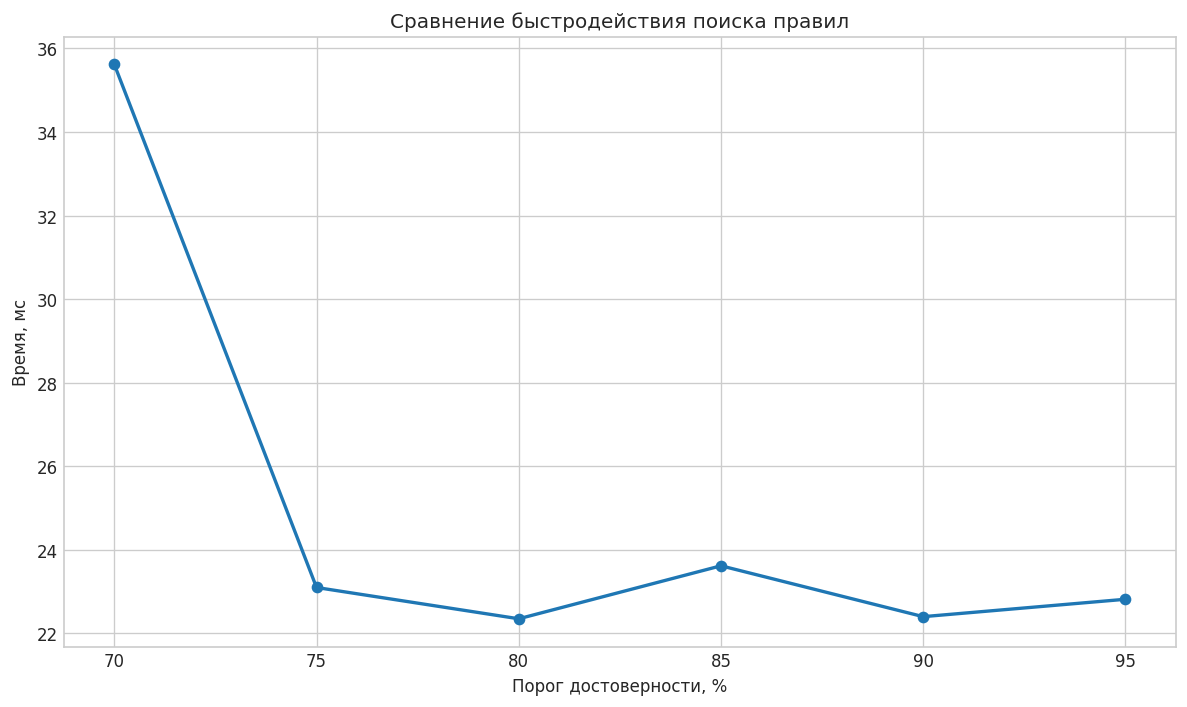

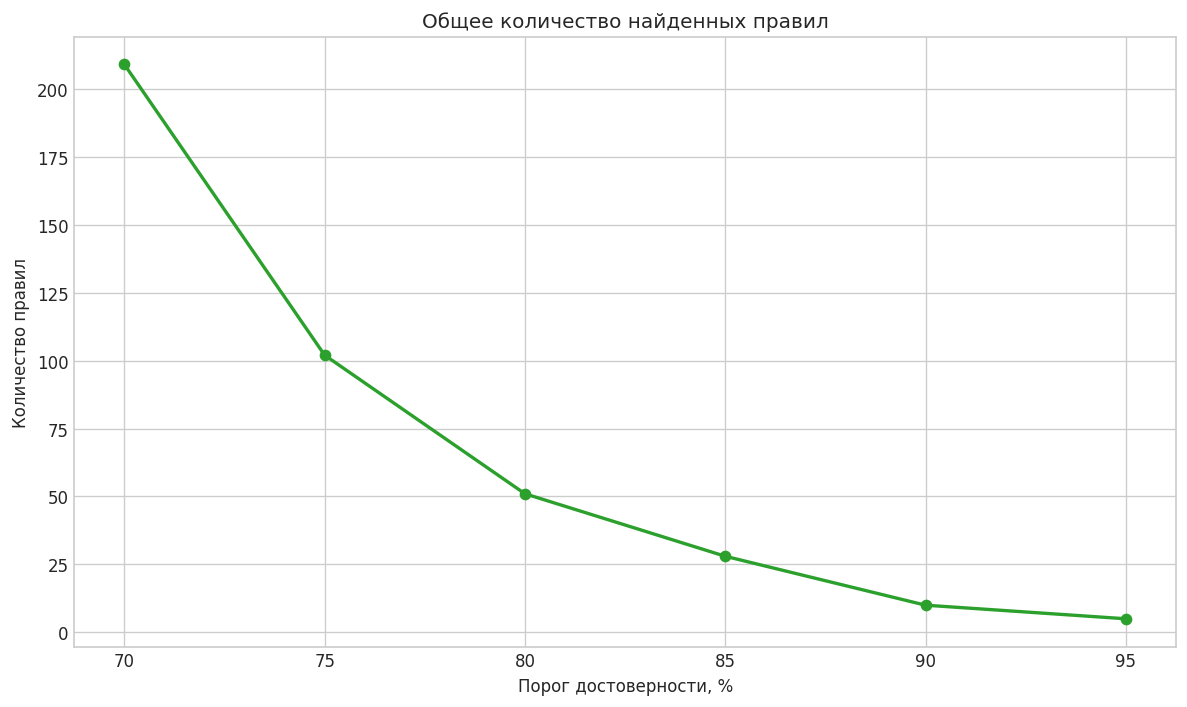

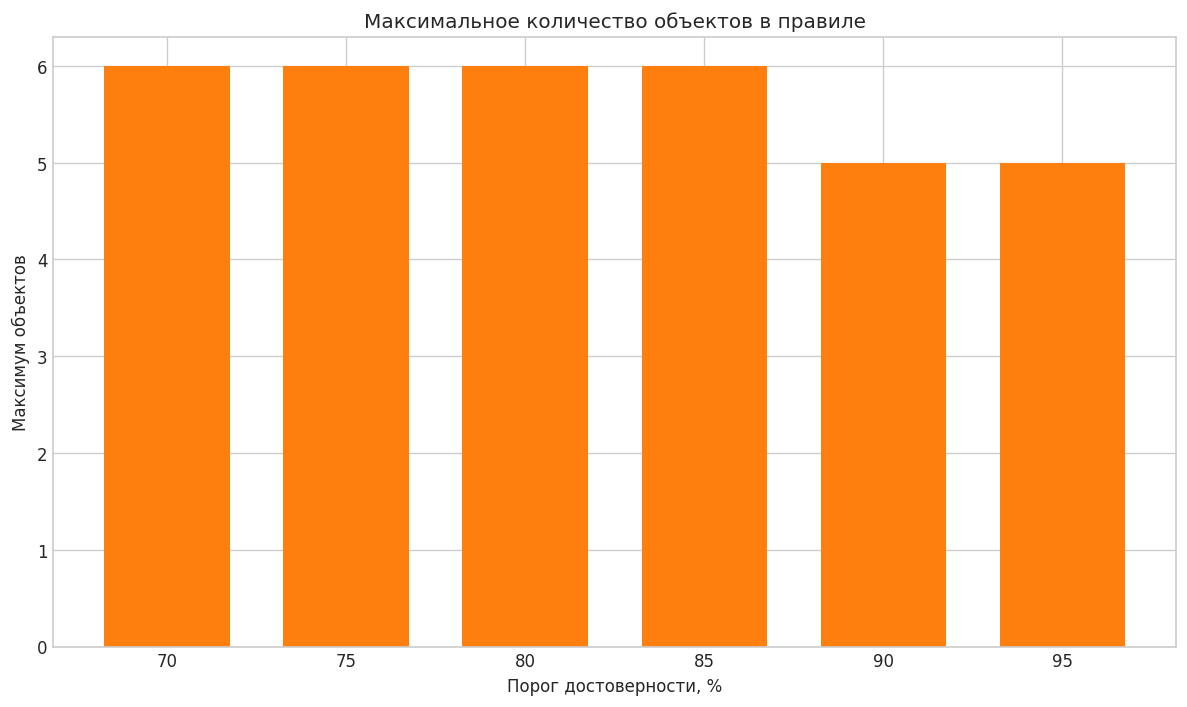

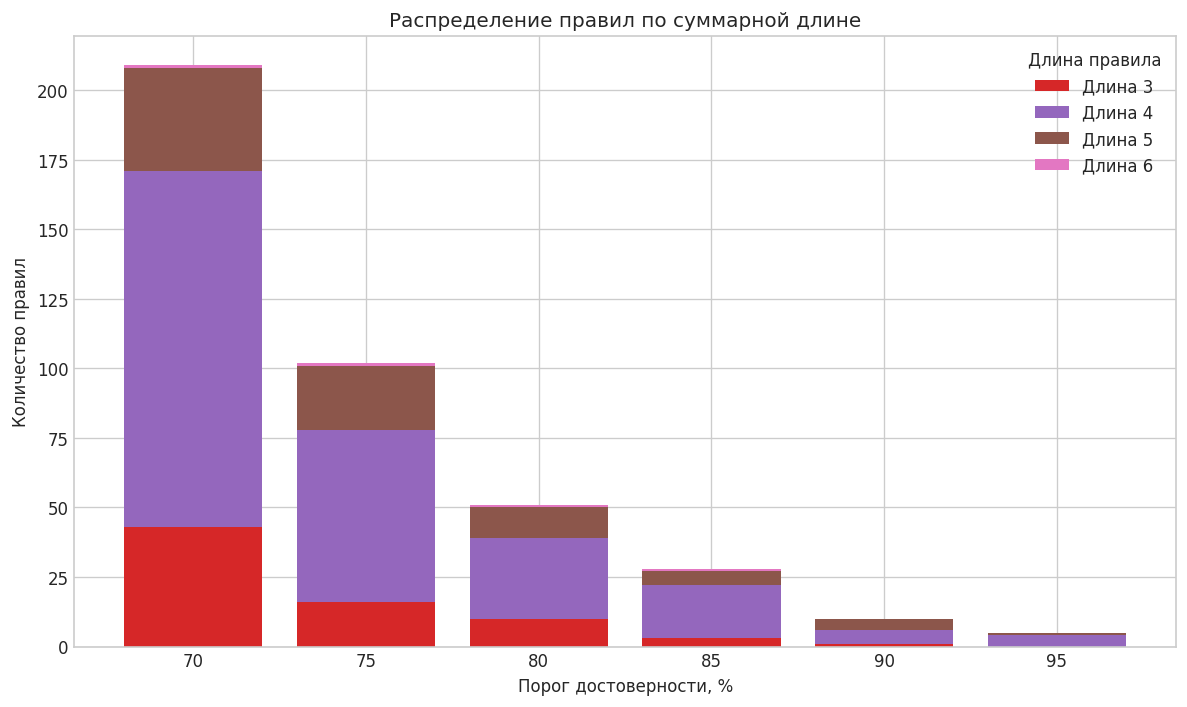

In [77]:
plot_df = prepare_plot_df(metrics_df)
plot_runtime_by_confidence(plot_df)
plot_total_rules_by_confidence(plot_df)
plot_max_items_by_confidence(plot_df)
plot_rule_length_distribution(rules_by_threshold)


## 5. Интерпретация результатов

In [78]:
def build_interpretation(metrics_view: pd.DataFrame, rules_catalog_df: pd.DataFrame) -> str:
    """Формирует итоговый текст интерпретации на основе таблиц метрик и правил.

    :param metrics_view: Отформатированная таблица метрик эксперимента.
    :param rules_catalog_df: Каталог правил для всех confidence-порогов.
    :return: Markdown-строка с ключевыми выводами по результатам.
    """
    best_volume = metrics_view.loc[metrics_view['Количество правил'].idxmax()]
    strict_volume = metrics_view.loc[metrics_view['Порог достоверности, %'] == 95].iloc[0]
    top_lift_rule = rules_catalog_df.sort_values('Lift', ascending=False).iloc[0]

    consequents = rules_catalog_df['Правило'].str.split('==>', n=1).str[1].str.strip()
    top_consequents = consequents.value_counts().head(3)
    top_consequents_text = '; '.join(f'{name} ({count})' for name, count in top_consequents.items())

    total_rules = int(metrics_view["Количество правил"].sum())
    filtered_rules = int(metrics_view["Правил с суммарной длиной <= 7"].sum())
    removed_rules = total_rules - filtered_rules
    if removed_rules == 0:
        filter_summary = '- После фильтрации по условию `antecedent + consequent <= 7` удалений нет.\n'
    else:
        filter_summary = (
            f'- После фильтрации по условию `antecedent + consequent <= 7` осталось **{filtered_rules}** '
            f'правил из **{total_rules}** (удалено **{removed_rules}**).\n'
        )

    interpretation_text = (
        f'- Наибольшее число правил получается при `confidence = {int(best_volume["Порог достоверности, %"])}%`: '
        f'**{int(best_volume["Количество правил"])}**.\n'
        f'- При повышении порога до `95%` остается **{int(strict_volume["Количество правил"])}** правил.\n'
        f'- Максимальная длина правила в эксперименте: **{int(metrics_view["Максимум объектов в правиле"].max())}** объектов.\n'
        f'{filter_summary}'
        f'- Правило с максимальным `lift`: **{top_lift_rule["Правило"]}** (`lift = {top_lift_rule["Lift"]}`).\n'
        f'- Наиболее частые консеквенты: **{top_consequents_text}**.\n\n'
        'Содержательно это означает, что в данных есть устойчивые сочетания товаров, '
        'но с ростом требуемой достоверности количество допустимых правил заметно снижается.'
    )
    return interpretation_text


if rules_catalog_df.empty:
    display(Markdown('При выбранных параметрах правила отсутствуют, интерпретация невозможна.'))
else:
    display(Markdown(build_interpretation(metrics_view, rules_catalog_df)))


- Наибольшее число правил получается при `confidence = 70%`: **209**.
- При повышении порога до `95%` остается **5** правил.
- Максимальная длина правила в эксперименте: **6** объектов.
- После фильтрации по условию `antecedent + consequent <= 7` удалений нет.
- Правило с максимальным `lift`: **грибной соус, картофель-фри, макароны ==> эскалоп** (`lift = 10.8058`).
- Наиболее частые консеквенты: **минеральная вода (224); макароны (116); молоко (27)**.

Содержательно это означает, что в данных есть устойчивые сочетания товаров, но с ростом требуемой достоверности количество допустимых правил заметно снижается.

## 6. Выводы

1. Поиск ассоциативных правил выполнен для `baskets.csv` с фиксированной поддержкой `0.1%`.
2. Порог достоверности варьировался от `70%` до `95%` с шагом `5%`.
3. Получен список правил в формате `антецедент ==> консеквент`; отдельно проверено условие длины правила `<= 7`.
4. Построены все требуемые диаграммы: время поиска, число правил, максимальная длина правила и число правил длины `<= 7`.
5. При повышении порога достоверности количество правил уменьшается, что соответствует ожидаемому поведению.
